In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
from make import load_heathy_data
from pathlib import Path
import os

spec = load_heathy_data()


Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1

In [4]:
len(spec)

1372

In [6]:
from validation_util import split

valid_spec = split(spec, int(len(spec) * 0.1))

In [7]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (33, 153)
Final shape: (33, 43)


In [8]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [9]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib

#custom_color_map = ListedColormap(["#F9F7ED", "#BAC8D3", "#647687"], name="custom_rgb_map")
#matplotlib.colormaps.register(name="custom_rgb_map", cmap=custom_color_map)

In [10]:
def get_x(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [11]:
def get_x_validate(i):
    arr = valid_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [12]:
block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    splitter=RandomSplitter(valid_pct=0.2),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_x,
)

In [13]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=8)

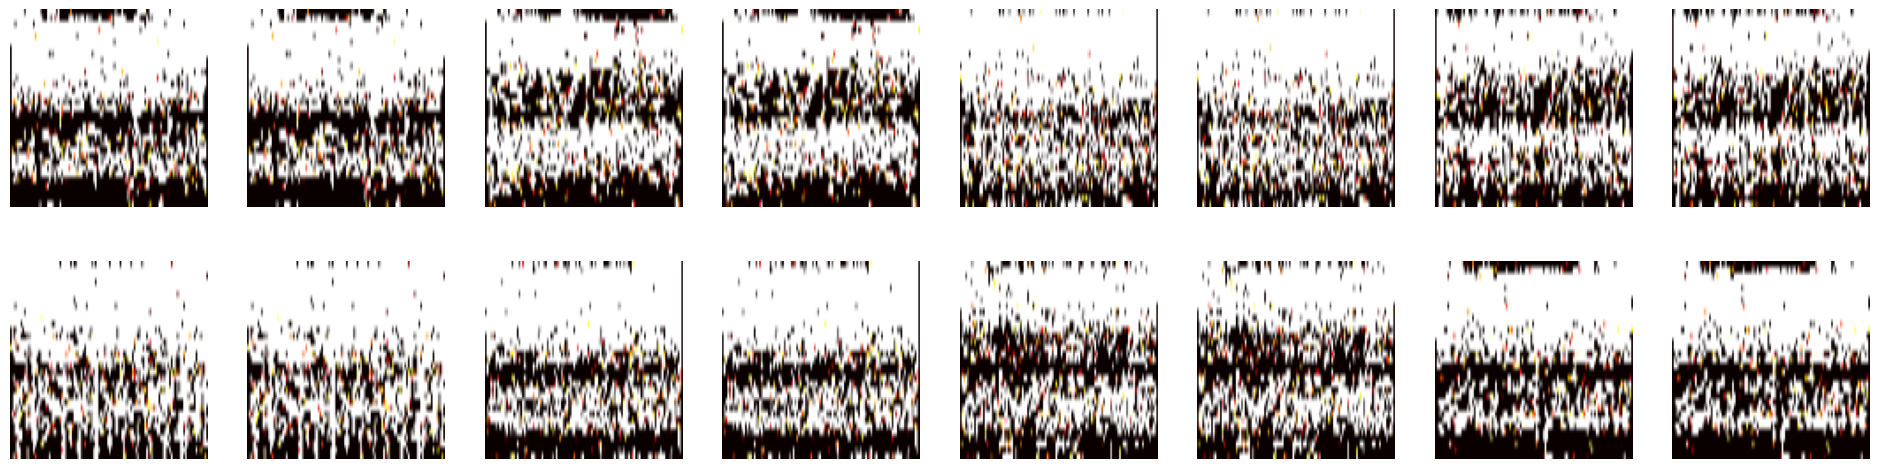

In [14]:
dls.show_batch()

In [15]:
import torch
import torch.nn as nn


class Experimental(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        
        self.encoder = nn.Sequential(

            nn.Conv2d(3,12,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(12,24,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(24,48,4,stride=2,padding=1),
            nn.ReLU(),

        )

        self.enc_channels = 48
        self.enc_h = 14
        self.enc_w = 14

        enc_flat = self.enc_channels * self.enc_h * self.enc_w
    
    
        # ---------- Bottleneck ----------
        self.to_latent = nn.Sequential(
            nn.Flatten(),                     # [B,48,14,14] -> [B,9408]
            nn.Linear(enc_flat, latent_dim),  # Compress to tiny latent
            nn.ReLU(inplace=True),
        )

        self.from_latent = nn.Sequential(
            nn.Linear(latent_dim, enc_flat),  # Expand back
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (self.enc_channels, self.enc_h, self.enc_w)) # -> [B,48,14,14]
        )
    
        # ---------- Decoder ----------
        self.decoder = nn.Sequential(
    
            nn.ConvTranspose2d(48,24,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(24,12,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(12,3,4,stride=2,padding=1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        encoder = self.encoder(x)
        z = self.to_latent(encoder)
        z_feat = self.from_latent(z)
        decoder = self.decoder(z_feat)
        return decoder
    
    def to_device(self, device):
        """Move model to specified device"""
        self.to(device)
        return self
    
    @property
    def device(self):
        """Get the device the model is on"""
        return next(self.parameters()).device

In [17]:
autoencoder = Experimental()

In [18]:
learn = Learner(dls, autoencoder, loss_func=F.mse_loss)

In [19]:
learn.fit_one_cycle(n_epoch = 25)

epoch,train_loss,valid_loss,time
0,0.180058,0.172782,00:05
1,0.130547,0.110848,00:01
2,0.104976,0.098498,00:01
3,0.085985,0.080507,00:01
4,0.078714,0.076713,00:01
5,0.076480,0.075749,00:01
6,0.075245,0.074472,00:01
7,0.074412,0.073808,00:01
8,0.073329,0.073803,00:01
9,0.073272,0.073404,00:01


In [20]:
learn.validate()

(#1) [0.07276947051286697]

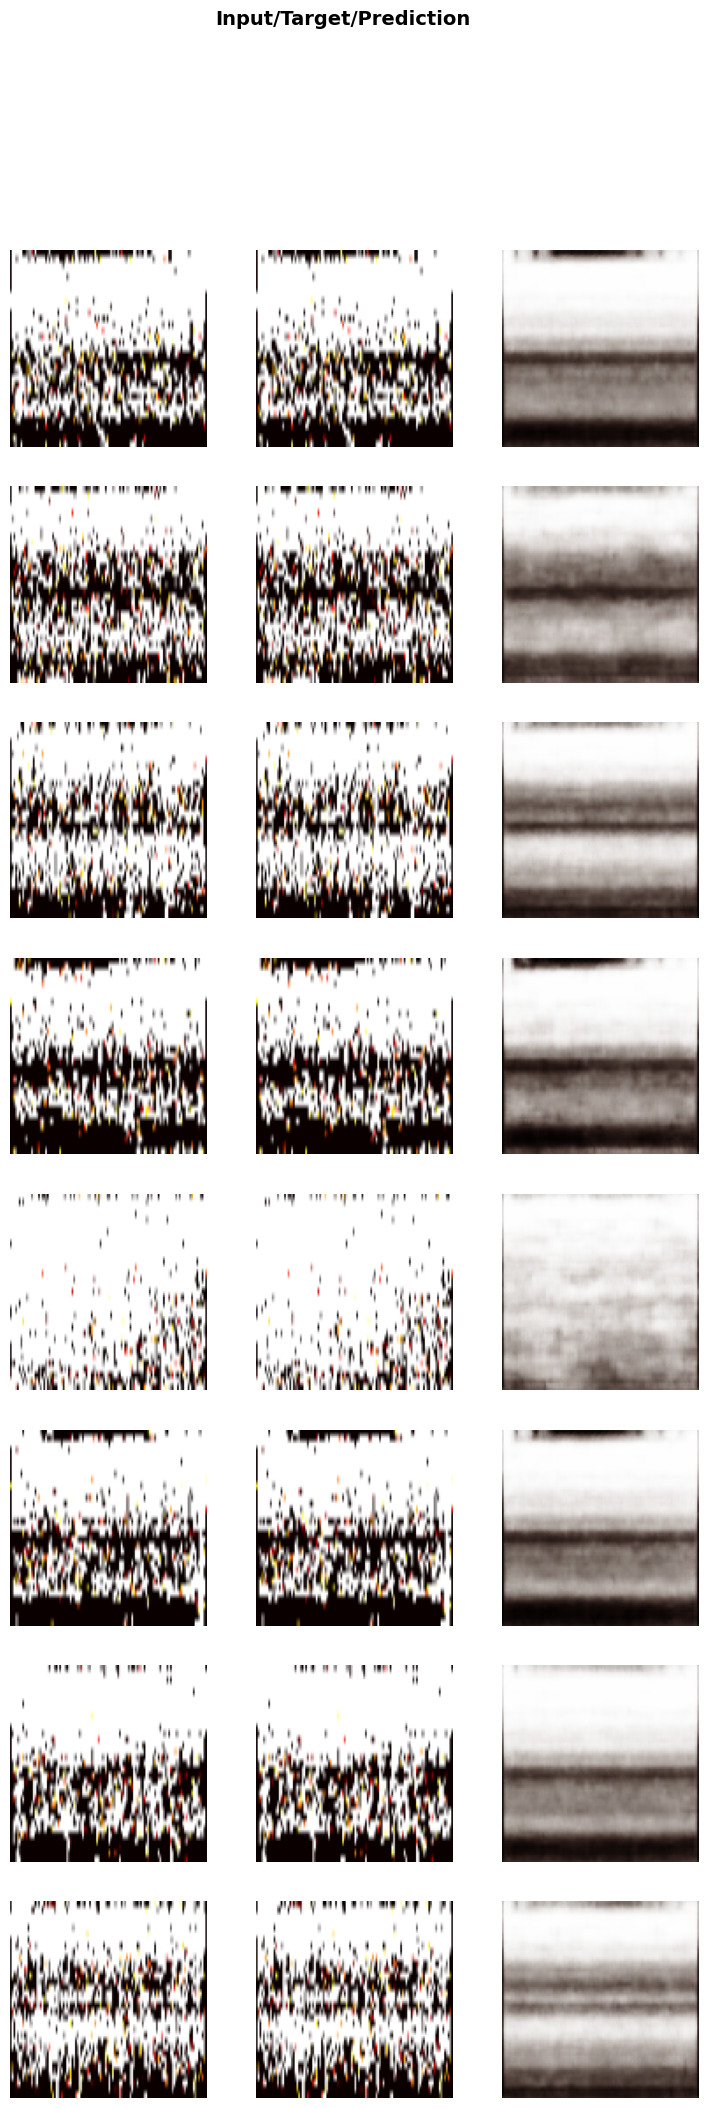

In [21]:
learn.show_results()

In [22]:
from make import load_primary_data
from validation_util import get_label_index

test_spec, test_labels = load_primary_data()

Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Gene

In [23]:
get_label_index("Fall", test_labels)

0

In [24]:
def get_x_test(i):
    arr = test_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [25]:
block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    get_items=lambda x: x,
    get_x=get_x_test,
    get_y=get_x_test,
)

In [26]:
items = list(range(len(test_spec)))   # or `range(N)`
test_dls = block.dataloaders(items, bs=8)

In [27]:
preds, targets, inputs = learn.get_preds(dl=test_dls, with_input=True)

In [28]:
preds.shape

torch.Size([960, 3, 112, 112])

In [29]:
targets.shape

torch.Size([960, 3, 112, 112])

In [30]:
inputs.shape

torch.Size([960, 3, 112, 112])

In [31]:
F.mse_loss(preds, targets)

TensorImage(0.0760)

In [32]:
F.l1_loss(preds, targets)

TensorImage(0.1977)

In [33]:
from kornia.metrics import psnr

psnr_value = psnr(preds, targets, max_val=1.0)

In [34]:
psnr_value

TensorImage(11.1903)

In [35]:
from validation_util import get_label_index

In [36]:
get_label_index("Fall", test_labels)

0

In [37]:
pred_tensor = learn.predict(get_x_test(0))[0]

<Axes: >

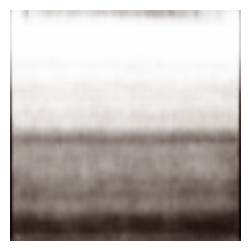

In [38]:
pred_tensor.show()

In [39]:
F.mse_loss(pred_tensor, get_x_test(0))

TensorImage(0.0753)

In [40]:
from plot_util import PlotUtil

pu = PlotUtil(test_spec)

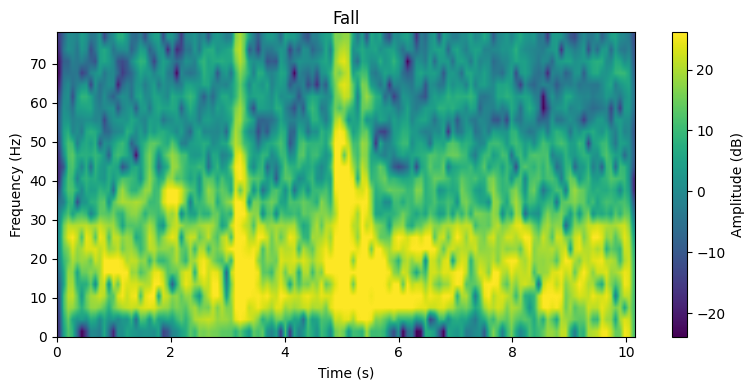

In [41]:
pu.show_spec(0, "Fall")

<Axes: >

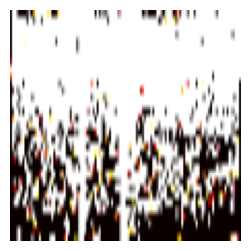

In [42]:
get_x_test(0).show()

In [43]:
psnr(pred_tensor, get_x_test(0), max_val=1.0)

TensorImage(11.2296)

In [44]:
len(valid_spec)

135

In [45]:
# unwrap like before
x = targets[0] if isinstance(targets, (list, tuple)) else targets
if isinstance(preds, (list, tuple)): preds = preds[0]
x = x.float().to(preds.device); preds = preds.float()

# per-sample MSE
recon_error = ((x - preds)**2).flatten(1).mean(1).cpu().numpy()

In [46]:
recon_error

array([0.05579633, 0.07473516, 0.0595691 , 0.09181505, 0.08487815,
       0.0812883 , 0.08361071, 0.07545358, 0.07605291, 0.06873951,
       0.08780632, 0.06409864, 0.0787091 , 0.07671753, 0.07305897,
       0.07726992, 0.07791109, 0.08158994, 0.07090089, 0.07668731,
       0.07039835, 0.0845424 , 0.0798047 , 0.0678323 , 0.07157911,
       0.0830352 , 0.06158575, 0.06939696, 0.08613984, 0.06538457,
       0.07297439, 0.07537378, 0.07754418, 0.06447928, 0.08338396,
       0.08225828, 0.06376118, 0.08809032, 0.08299688, 0.07361161,
       0.07528508, 0.07372814, 0.07187672, 0.08360276, 0.08573852,
       0.06426695, 0.06592323, 0.06291991, 0.07701137, 0.05988339,
       0.0649073 , 0.0755811 , 0.07465041, 0.07412597, 0.07340989,
       0.06682299, 0.07349858, 0.06097291, 0.08398826, 0.06105524,
       0.07738089, 0.06463131, 0.07945332, 0.08814041, 0.08461969,
       0.08226481, 0.07471713, 0.07215278, 0.07730606, 0.06768007,
       0.06021079, 0.06837145, 0.08492094, 0.09031953, 0.06431

In [47]:
len(recon_error)

960

In [48]:
threshold = np.percentile(recon_error, 80)

In [63]:
threshold_2 = np.percentile(recon_error, 99)

In [66]:
threshold_2

np.float32(0.09693604)

In [49]:
threshold

np.float32(0.083736055)

In [50]:
def test_normal() -> list:
    result = []
    for i in range(len(test_spec)):
        if test_labels[i] == "Not Fall":
            result.append(F.mse_loss(get_x_test(i), learn.predict(get_x_test(i))[0]))

    return result

def test_anomaly() -> list:
    result = []
    for i in range(len(test_spec)):
        if test_labels[i] == "Fall":
            result.append(F.mse_loss(get_x_test(i), learn.predict(get_x_test(i))[0]))
    
    return result

rcon_err_faulty = test_anomaly()
rcon_err_norm = test_normal()

In [51]:
rcon_err_faulty

[TensorImage(0.0753),
 TensorImage(0.0743),
 TensorImage(0.0819),
 TensorImage(0.0800),
 TensorImage(0.0706),
 TensorImage(0.0731),
 TensorImage(0.0858),
 TensorImage(0.0789),
 TensorImage(0.0688),
 TensorImage(0.0721),
 TensorImage(0.0838),
 TensorImage(0.0779),
 TensorImage(0.0772),
 TensorImage(0.0715),
 TensorImage(0.0787),
 TensorImage(0.0838),
 TensorImage(0.0704),
 TensorImage(0.0706),
 TensorImage(0.0866),
 TensorImage(0.0788),
 TensorImage(0.0765),
 TensorImage(0.0737),
 TensorImage(0.0848),
 TensorImage(0.0859),
 TensorImage(0.0700),
 TensorImage(0.0716),
 TensorImage(0.0850),
 TensorImage(0.0803),
 TensorImage(0.0708),
 TensorImage(0.0709),
 TensorImage(0.0793),
 TensorImage(0.0733),
 TensorImage(0.0706),
 TensorImage(0.0694),
 TensorImage(0.0899),
 TensorImage(0.0819),
 TensorImage(0.0746),
 TensorImage(0.0666),
 TensorImage(0.0840),
 TensorImage(0.0781),
 TensorImage(0.0690),
 TensorImage(0.0761),
 TensorImage(0.0868),
 TensorImage(0.0762),
 TensorImage(0.0629),
 TensorIma

In [52]:
rcon_err_norm

[TensorImage(0.0698),
 TensorImage(0.0690),
 TensorImage(0.0752),
 TensorImage(0.0776),
 TensorImage(0.0617),
 TensorImage(0.0589),
 TensorImage(0.0815),
 TensorImage(0.0718),
 TensorImage(0.0586),
 TensorImage(0.0620),
 TensorImage(0.0804),
 TensorImage(0.0717),
 TensorImage(0.0678),
 TensorImage(0.0645),
 TensorImage(0.0823),
 TensorImage(0.0771),
 TensorImage(0.0673),
 TensorImage(0.0624),
 TensorImage(0.0815),
 TensorImage(0.0764),
 TensorImage(0.0664),
 TensorImage(0.0656),
 TensorImage(0.0813),
 TensorImage(0.0742),
 TensorImage(0.0614),
 TensorImage(0.0612),
 TensorImage(0.0789),
 TensorImage(0.0755),
 TensorImage(0.0696),
 TensorImage(0.0657),
 TensorImage(0.0718),
 TensorImage(0.0696),
 TensorImage(0.0612),
 TensorImage(0.0611),
 TensorImage(0.0824),
 TensorImage(0.0748),
 TensorImage(0.0684),
 TensorImage(0.0648),
 TensorImage(0.0830),
 TensorImage(0.0696),
 TensorImage(0.0641),
 TensorImage(0.0643),
 TensorImage(0.0765),
 TensorImage(0.0745),
 TensorImage(0.0600),
 TensorIma

In [53]:
np.median(rcon_err_norm)

np.float32(0.07211448)

In [54]:
np.median(rcon_err_faulty)

np.float32(0.08030907)

In [55]:
np.percentile(rcon_err_norm, 95)

np.float32(0.08354992)

In [56]:
np.percentile(rcon_err_faulty, 50)

np.float32(0.08030907)

In [57]:
np.percentile(rcon_err_faulty, 10)

np.float32(0.07039532)

In [58]:
len(rcon_err_faulty)

600

In [67]:
i = 0
for j in range(len(rcon_err_faulty)):
    print(rcon_err_faulty[j])
    if rcon_err_faulty[j] >= threshold:
        i += 1
print(threshold)
print(i)

TensorImage(0.0753)
TensorImage(0.0743)
TensorImage(0.0819)
TensorImage(0.0800)
TensorImage(0.0706)
TensorImage(0.0731)
TensorImage(0.0858)
TensorImage(0.0789)
TensorImage(0.0688)
TensorImage(0.0721)
TensorImage(0.0838)
TensorImage(0.0779)
TensorImage(0.0772)
TensorImage(0.0715)
TensorImage(0.0787)
TensorImage(0.0838)
TensorImage(0.0704)
TensorImage(0.0706)
TensorImage(0.0866)
TensorImage(0.0788)
TensorImage(0.0765)
TensorImage(0.0737)
TensorImage(0.0848)
TensorImage(0.0859)
TensorImage(0.0700)
TensorImage(0.0716)
TensorImage(0.0850)
TensorImage(0.0803)
TensorImage(0.0708)
TensorImage(0.0709)
TensorImage(0.0793)
TensorImage(0.0733)
TensorImage(0.0706)
TensorImage(0.0694)
TensorImage(0.0899)
TensorImage(0.0819)
TensorImage(0.0746)
TensorImage(0.0666)
TensorImage(0.0840)
TensorImage(0.0781)
TensorImage(0.0690)
TensorImage(0.0761)
TensorImage(0.0868)
TensorImage(0.0762)
TensorImage(0.0629)
TensorImage(0.0759)
TensorImage(0.0872)
TensorImage(0.0806)
TensorImage(0.0669)
TensorImage(0.0663)


In [68]:
i / len(rcon_err_faulty)

0.33166666666666667

In [61]:
def test(input : Tensor):
    input_mse = F.mse_loss(input, learn.predict(input)[0])
    if input_mse > threshold:
        return "Fall"
    
    return "Not Fall"

In [62]:
test(get_x_test(0))

'Not Fall'

## Reconstrcution 
- The Peak signal to noise ratio (psnr) is a metric that shows how well the model can reconstruct details.
- The psnr is low, indicating that the model cannot reconstruct the images very well.
- mse (mean squared error) is a metric to see how far from the origional the reconstruction is. 
- As there is no difference in the mse from reconstructing heathly vs unhealthy images is a key
- We see that the psnr is low, it fails to reconstruct the input accurately, indicating that the model did not learn to reconstruct the healty data.
- Reason: Theory is a too narrow dataset, with too much variation. Not a good fit for this application. 

- The samples in the dataset are too similary for the autoencoder to work. The difference should be more significant. The healthy data should also have a clear patterns, and if there is more patterns defined as healthy, the dataset should be larger to capture this. The "anomalies" is just interperted as more clumsy versions of the motions it has already seen.  

- Using supervised learning features the small differences, while the autoencoder attempts to recreate them as good as possible. The more events that is considered healthy, the more samples you need. 